In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ast
import math
import platform

pd.set_option("display.float_format", "{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams["font.family"] = "NanumGothic"

In [2]:
df_port = pd.read_csv("../dataset/portfolio.csv", index_col=0)  # 프로모션의 종류
df_prof = pd.read_csv("../dataset/profile.csv", index_col=0)  # 참여 고객 정보
df_tran = pd.read_csv("../dataset/transcript.csv", index_col=0)  #
df_menu = pd.read_csv("../dataset/starbucks_menu_260112.csv", index_col=0)


for name, df in [
    ("portfolio", df_port),
    ("profile", df_prof),
    ("transcript", df_tran),
    ("starbucks_menu_260112", df_menu),
]:
    print(f"\n===== {name} =====")
    print(df.shape)
    print(df.dtypes)
    print(df.isna().sum())
    print(df.head(3))


===== portfolio =====
(10, 6)
reward        int64
channels        str
difficulty    int64
duration      int64
offer_type      str
id              str
dtype: object
reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64
   reward                              channels  difficulty  duration  \
0      10         ['email', 'mobile', 'social']          10         7   
1      10  ['web', 'email', 'mobile', 'social']          10         5   
2       0            ['web', 'email', 'mobile']           0         4   

      offer_type                                id  
0           bogo  ae264e3637204a6fb9bb56bc8210ddfd  
1           bogo  4d5c57ea9a6940dd891ad53e9dbe8da0  
2  informational  3f207df678b143eea3cee63160fa8bed  

===== profile =====
(17000, 5)
gender                  str
age                   int64
id                      str
became_member_on      int64
income              float64
dtype: object
gender              2175
age       

In [3]:
df_port.sort_values("offer_type")

,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837


In [ ]:
df_prof["id"].count()

np.int64(17000)

In [5]:
df_tran

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


In [ ]:
df_menu

,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
0,9200000002487,나이트로 바닐라 크림,80,2,1,2.7,0,40,10,232,5,10
1,9200000000479,나이트로 콜드 브루,5,0,0,0,0,5,0,245,0,0
2,9200000002081,돌체 콜드 브루,220,6,6,10,0,80,22,155,20,24
3,9200000002407,리저브 나이트로,5,0,0,0,0,0,0,190,0,0
4,9200000002093,리저브 콜드 브루,5,0,0,0,0,0,0,190,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
190,9200000003255,아이스 더블 에스프레소 크림 라떼,190,7,5,9,0,85,20,90,15,21
191,9200000006643,아이스 프렌즈 얼 그레이 베리 티 라떼,280,12,4,15,0,60,26,30,15,33
192,9200000006640,프렌즈 얼 그레이 베리 티 라떼,280,12,4,15,0,60,26,30,15,33
193,9200000006646,유자 배 캐모마일 티,190,0,0,0.2,0,0,33,0,0,52


### | df_prof의 **id(고유 유저 정보)** 와 df_tran의 **person(활동 로그)** 
: 1 대 N(다수) 관계

In [6]:
# df_prof의 id 중 df_tran의 person에 존재하는 데이터 개수
# "거래 경험이 있는 회원이 몇 명?
matching_count = df_prof["id"].isin(df_tran["person"]).sum()
print(f"매칭되는 ID 개수: {matching_count}")

# df_prof에 등록된 유저는, "프로모션 참여이력, 또는 거래 내역이 있는 유저"

매칭되는 ID 개수: 17000


In [7]:
# "회원들이 발생시킨 총 거래 건수가 몇 건?"
matching_count = df_tran["person"].isin(df_prof["id"]).sum()
print(f"매칭되는 ID 개수: {matching_count}")

# df_tran(거래 내역) 전체 행 중에, "유저(df_prof에 있는 ID) 17,000명이 발생시킨 거래 건수"가 총 306,534건

매칭되는 ID 개수: 306534


#### 1인당 평균 거래 횟수
: 전체 회원 중 거래 경험이 있는 17,000명이 총 306,534건의 거래를 발생시켰으므로, 1인당 평균 약 18건의 거래
( 306,534 / 17,000 = 18.03 )

In [8]:
# 유저별 거래 건수 계산
user_counts = df_tran["person"].value_counts()

# 요약 통계량 확인 (최저, 최고, 평균, 중앙값 등)
print(user_counts.describe())

count   17000.00
mean       18.03
std         6.85
min         1.00
25%        13.00
50%        17.00
75%        23.00
max        51.00
Name: count, dtype: float64


In [10]:
# df_tran에서 각 person별로 거래가 몇 건인지, 상위 5명
top_users = df_tran["person"].value_counts().head(10)
print("--- 거래를 가장 많이 한 유저 TOP 5 ---")
print(top_users)

--- 거래를 가장 많이 한 유저 TOP 5 ---
person
94de646f7b6041228ca7dec82adb97d2    51
8dbfa485249f409aa223a2130f40634a    49
79d9d4f86aca4bed9290350fb43817c2    48
d0a80415b84c4df4908b8403b19765e3    48
5e60c6aa3b834e44b822ea43a3efea26    48
b1f4ece7d49342628a9ed77aee2cde58    46
28681c16026943e68f26feaccab0907f    46
a42ed50acc4d4b25bca647c9e0b916ad    46
bd2cdd691aca4bb0a0e039979ee5de5c    46
ab25fd6fbd5040f880751921e4029757    44
Name: count, dtype: int64


# | **portfolio**

In [12]:
df_port.isna().sum()

reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64

In [13]:
# channels 리스트가 아닌 문자열 모음이므로 변환 필요
print(df_port["channels"])

0           ['email', 'mobile', 'social']
1    ['web', 'email', 'mobile', 'social']
2              ['web', 'email', 'mobile']
3              ['web', 'email', 'mobile']
4                        ['web', 'email']
5    ['web', 'email', 'mobile', 'social']
6    ['web', 'email', 'mobile', 'social']
7           ['email', 'mobile', 'social']
8    ['web', 'email', 'mobile', 'social']
9              ['web', 'email', 'mobile']
Name: channels, dtype: str


In [14]:
# channels: 문자열을 리스트로 변환
df_port["channels"] = df_port["channels"].apply(ast.literal_eval)

# 리스트 -> 이진 컬럼
# (리스트는 태블로에서 사용 불가)
for ch in ["web", "email", "mobile", "social"]:
    df_port[f"ch_{ch}"] = df_port["channels"].apply(lambda x: 1 if ch in x else 0)

# 파생변수 - 채널 수 (몇 개 채널로 발송됐는지)
# 채널을 많이 쓰거나 적게 쓸수록 어떤 변화가 있는지 관찰 위해
df_port["channel_count"] = df_port["channels"].apply(len)

print("✅ portfolio 전처리 완료")
print(df_port[["offer_type", "ch_web", "ch_email", "ch_mobile", "ch_social", "channel_count"]])

✅ portfolio 전처리 완료
      offer_type  ch_web  ch_email  ch_mobile  ch_social  channel_count
0           bogo       0         1          1          1              3
1           bogo       1         1          1          1              4
2  informational       1         1          1          0              3
3           bogo       1         1          1          0              3
4       discount       1         1          0          0              2
5       discount       1         1          1          1              4
6       discount       1         1          1          1              4
7  informational       0         1          1          1              3
8           bogo       1         1          1          1              4
9       discount       1         1          1          0              3


# | **profile** 

In [16]:
# 결측치 확인
df_prof.isna().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [17]:
# age: 범주화
df_prof["age"].describe()

count   17000.00
mean       62.53
std        26.74
min        18.00
25%        45.00
50%        58.00
75%        73.00
max       118.00
Name: age, dtype: float64

In [18]:
# age=118은 결측값으로 처리
df_prof["age"] = df_prof["age"].replace(118, pd.NA)

In [19]:
# gender: 결측치 'Unknown' 표시
df_prof["gender"] = df_prof["gender"].fillna("Unknown")

In [20]:
# became_member_on: datetime 으로 변환
df_prof["became_member_on"] = pd.to_datetime(df_prof["became_member_on"].astype(str), format="%Y%m%d")

In [21]:
# 파생변수
df_prof["member_year"] = df_prof["became_member_on"].dt.year
df_prof["member_month"] = df_prof["became_member_on"].dt.month

In [22]:
df_prof["became_member_on"].describe()

count                         17000
mean     2017-02-23 13:12:10.164706
min             2013-07-29 00:00:00
25%             2016-05-26 00:00:00
50%             2017-08-02 00:00:00
75%             2017-12-30 00:00:00
max             2018-07-26 00:00:00
Name: became_member_on, dtype: object

In [23]:
base_date = df_prof["became_member_on"].max()
df_prof["tenure_days"] = (base_date - df_prof["became_member_on"]).dt.days

print(f"기준일: {base_date.date()}")
print(df_prof["tenure_days"].describe())

기준일: 2018-07-26
count   17000.00
mean      517.45
std       411.22
min         0.00
25%       208.00
50%       358.00
75%       791.00
max      1823.00
Name: tenure_days, dtype: float64


In [ ]:
df_prof[["income"]].describe()

In [24]:
# 소득 구간
income_bins = [0, 40000, 60000, 80000, 100000, 200000]
income_labels = ["~4만", "4~6만", "6~8만", "8~10만", "10만+"]
df_prof["income_group"] = pd.cut(df_prof["income"], bins=income_bins, labels=income_labels)

print(df_prof["income_group"].value_counts(dropna=False))
print("income 결측 수:", df_prof["income"].isna().sum())

income_group
6~8만     4567
4~6만     4558
8~10만    2559
NaN      2175
~4만      2135
10만+     1006
Name: count, dtype: int64
income 결측 수: 2175


In [25]:
print("\n가입연도 분포:")
print(df_prof["member_year"].value_counts())
print("\ngender 분포:")
print(df_prof["gender"].value_counts(dropna=False))


가입연도 분포:
member_year
2017    6469
2018    4198
2016    3526
2015    1830
2014     691
2013     286
Name: count, dtype: int64

gender 분포:
gender
M          8484
F          6129
Unknown    2175
O           212
Name: count, dtype: int64


# | **transcript**

In [26]:
df_tran.isna().sum()

person    0
event     0
value     0
time      0
dtype: int64

In [27]:
print(type(df_tran["value"].iloc[0]))

<class 'str'>


In [28]:
df_tran["time"]

0           0
1           0
2           0
3           0
4           0
         ... 
306529    714
306530    714
306531    714
306532    714
306533    714
Name: time, Length: 306534, dtype: int64

In [29]:
df_tran["value_keys"] = df_tran["value"].apply(lambda x: str(tuple(sorted(ast.literal_eval(x).keys()))))

pd.crosstab(df_tran["event"], df_tran["value_keys"])

value_keys,"('amount',)","('offer id',)","('offer_id', 'reward')"
event,,,
offer completed,0,0,33579
offer received,0,76277,0
offer viewed,0,57725,0
transaction,138953,0,0


- 크로스탭 결과를 보면 offer completed의 value key가 다른 이벤트와 다른 것을 알 수 있음.

In [30]:
# value_keys 컬럼 제거
df_tran.drop(columns=["value_keys"], inplace=True)

In [31]:
df_tran["value"].apply(lambda x: list(ast.literal_eval(x).keys())[0]).value_counts()

value
amount      138953
offer id    134002
offer_id     33579
Name: count, dtype: int64

In [33]:
# value: 실제 자료형으로 변환 필요
# 주의: received/viewed → 'offer id' (공백)
#       completed → 'offer_id'  (언더스코어)  ← key 이름 다름!


def split_value(log):
    d = ast.literal_eval(log["value"])  # 문자열을 딕셔너리 자료형으로 변환

    if log["event"] == "transaction":
        return pd.Series({"amount": d.get("amount"), "offer_id": None, "reward_amount": None})

    elif log["event"] == "offer completed":
        return pd.Series(
            {"amount": None, "offer_id": d.get("offer_id"), "reward_amount": d.get("reward")}
        )  # 리워드 금액 추출

    else:
        return pd.Series({"amount": None, "offer_id": d.get("offer id"), "reward_amount": None})


# 모든 행에 함수(split_value) 적용
# value 컬럼 하나를 amount, offer_id, reward_amount 3개로 쪼개어 새 데이터프레임 생성
parsed = df_tran.apply(split_value, axis=1)
# 원본 transcript 옆에 parsed 데이터프레임 붙이기
df_tran = pd.concat([df_tran, parsed], axis=1)
df_tran.drop(columns=["value"], inplace=True)  # 원본 value컬럼 제거


# time -> day
# 시간 단위를 일단위로 바꾸기(시계열 분석 편의 위해)
df_tran["day"] = df_tran["time"] // 24

In [35]:
print(df_tran["event"].value_counts())
print(df_tran[["person", "event", "amount", "offer_id", "day"]].head(8))

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64
                             person           event  amount  \
0  78afa995795e4d85b5d9ceeca43f5fef  offer received     NaN   
1  a03223e636434f42ac4c3df47e8bac43  offer received     NaN   
2  e2127556f4f64592b11af22de27a7932  offer received     NaN   
3  8ec6ce2a7e7949b1bf142def7d0e0586  offer received     NaN   
4  68617ca6246f4fbc85e91a2a49552598  offer received     NaN   
5  389bc3fa690240e798340f5a15918d5c  offer received     NaN   
6  c4863c7985cf408faee930f111475da3  offer received     NaN   
7  2eeac8d8feae4a8cad5a6af0499a211d  offer received     NaN   

                           offer_id  day  
0  9b98b8c7a33c4b65b9aebfe6a799e6d9    0  
1  0b1e1539f2cc45b7b9fa7c272da2e1d7    0  
2  2906b810c7d4411798c6938adc9daaa5    0  
3  fafdcd668e3743c1bb461111dcafc2a4    0  
4  4d5c57ea9a6940dd891ad53e9dbe8da0    0  
5  f19421c1d4aa40978ebb69ca19b0e20d   

# | viewed 없이 completed만 있는 경우

- viewed 후 completed -> 캠페인이 행동을 유도한 것 <- 진짜 마케팅 효과
- viewed 없이 completed <- 캠페인 효과 아님

In [ ]:
# 년도별 신규 가입자 수
df_prof["year"] = df_prof["became_member_on"].dt.year

year_counts = df_prof["year"].value_counts().sort_index()
year_ratio = df_prof["year"].value_counts(normalize=True).sort_index() * 100

print(year_counts)

year
2013     286
2014     691
2015    1830
2016    3526
2017    6469
2018    4198
Name: count, dtype: int64


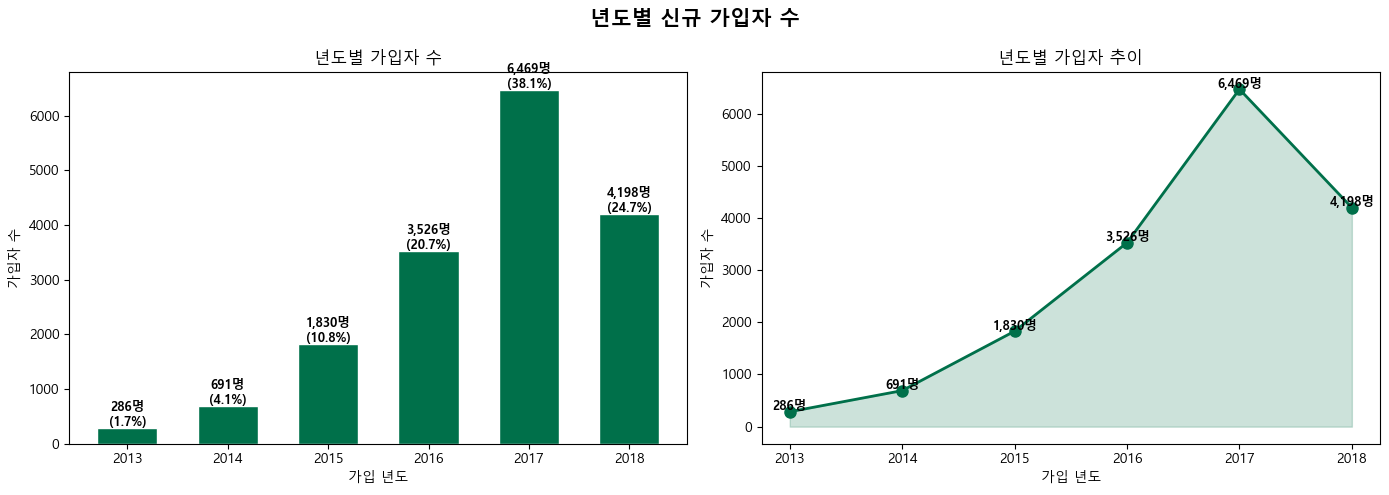

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("년도별 신규 가입자 수", fontsize=15, fontweight="bold")

# 막대 차트
bars = axes[0].bar(year_counts.index.astype(str), year_counts.values, color="#00704A", edgecolor="white", width=0.6)
axes[0].set_title("년도별 가입자 수")
axes[0].set_xlabel("가입 년도")
axes[0].set_ylabel("가입자 수")
for bar, cnt, ratio in zip(bars, year_counts.values, year_ratio.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{cnt:,}명\n({ratio:.1f}%)",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# 추세선 (꺾은선)
axes[1].plot(year_counts.index.astype(str), year_counts.values, marker="o", color="#00704A", linewidth=2, markersize=8)
axes[1].fill_between(year_counts.index.astype(str), year_counts.values, alpha=0.2, color="#00704A")
axes[1].set_title("년도별 가입자 추이")
axes[1].set_xlabel("가입 년도")
axes[1].set_ylabel("가입자 수")
for x, cnt in zip(year_counts.index.astype(str), year_counts.values):
    axes[1].text(x, cnt + 30, f"{cnt:,}명", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

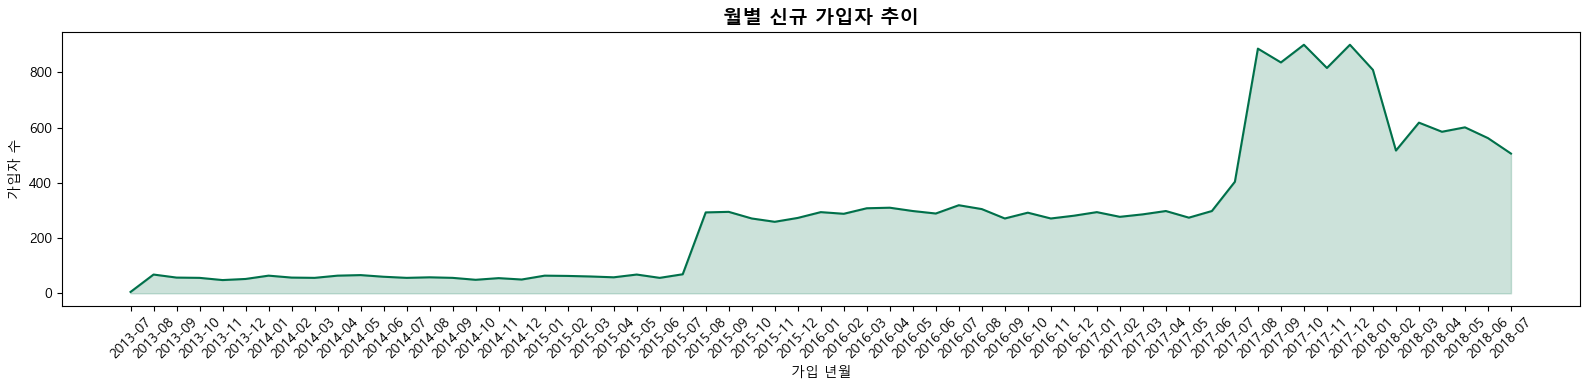

In [ ]:
# 월별 가입자 추이 (년도-월)
df_prof["year_month"] = df_prof["became_member_on"].dt.to_period("M")
ym_counts = df_prof["year_month"].value_counts().sort_index()

plt.figure(figsize=(16, 4))
plt.plot(ym_counts.index.astype(str), ym_counts.values, color="#00704A", linewidth=1.5)
plt.fill_between(ym_counts.index.astype(str), ym_counts.values, alpha=0.2, color="#00704A")
plt.title("월별 신규 가입자 추이", fontsize=14, fontweight="bold")
plt.xlabel("가입 년월")
plt.ylabel("가입자 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()